Lendo arquivo: 3491B_240506-155911.hdr


c:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\.venv\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


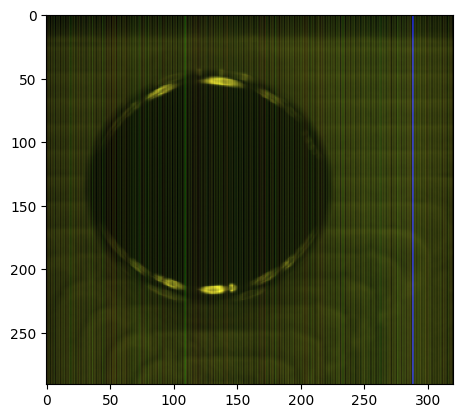

Lendo arquivo: 3491B_240506-155911.raw


OSError: Unable to determine file type or type not supported.

In [1]:
import os
import spectral as spy
import matplotlib.pyplot as plt

# Caminho para a pasta data_processed
data_dir = r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed"

# Lista todos os arquivos da pasta
files = [f for f in os.listdir(data_dir) if f.endswith(('.hdr', '.raw', '.bil', '.bip', '.bsq'))]

# Loop sobre os arquivos encontrados
for file in files:
    filepath = os.path.join(data_dir, file)
    print(f"Lendo arquivo: {file}")
    
    # Lê a imagem hiperespectral
    img = spy.open_image(filepath)
    
    # Plota uma visualização RGB (se possível)
    spy.imshow(img, (29, 19, 9))  # usa bandas arbitrárias para RGB
    plt.show()


In [ ]:
pip install opencv-python


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ------- -------------------------------- 7.3/39.0 MB 46.3 MB/s eta 0:00:01
   -------------------- ------------------- 19.9/39.0 MB 58.9 MB/s eta 0:00:01
   ---------------------------- ----------- 27.5/39.0 MB 49.7 MB/s eta 0:00:01
   ---------------------------------------  38.8/39.0 MB 52.1 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 41.5 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----------------------------- ---------- 9.4/12.6 MB 46.9 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 42.4 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.3.1

    Uninstalling numpy-2.3.1:

      Successfully uninstalled numpy-2.3.1

   ---------------------------------------- 0/2 [numpy]
   -----------------------

  You can safely remove it manually.
  You can safely remove it manually.


c:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\.venv\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)
C:\Users\LucAA\AppData\Local\Temp\ipykernel_15708\1835771488.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  roi = img * mask3d
C:\Users\LucAA\AppData\Local\Temp\ipykernel_15708\1835771488.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


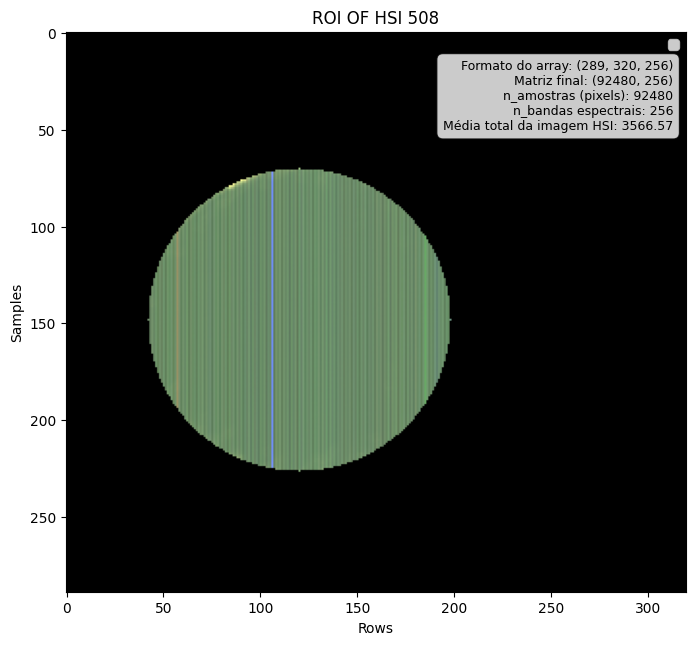

In [ ]:
import spectral
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = spectral.open_image(
   r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\351_1_240506-160920.hdr"
).load()

rgb = spectral.get_rgb(img, [50, 30, 10])

gray = cv2.cvtColor((rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (7, 7), 2)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=50,
    maxRadius=200
)

mask = np.zeros(gray.shape, dtype=np.uint8)

if circles is not None:
    x, y, r = circles[0][0]
    cv2.circle(mask, (int(x), int(y)), int(r), 1, thickness=-1)

mask3d = np.repeat(mask[:, :, np.newaxis], img.shape[2], axis=2)

roi = img * mask3d

roi_rgb = spectral.get_rgb(roi, [50, 30, 10])
roi_rgb_norm = roi_rgb / roi_rgb.max()

altura, largura, n_bandas = img.shape
img_array = img 

n_amostras = altura * largura

# Transformar a imagem em matriz 2D (pixels x bandas)
espectros_matriz = img.reshape(n_amostras, n_bandas)

media_total = espectros_matriz.mean()


plt.figure(figsize=(8, 8))
plt.imshow(roi_rgb_norm)
plt.title("ROI OF HSI 508")
plt.xlabel("Rows")
plt.ylabel("Samples")

plt.legend()

info_text = (
    f"Formato do array: {img_array.shape}\n"
    f"Matriz final: {espectros_matriz.shape}\n"
    f"n_amostras (pixels): {n_amostras}\n"
    f"n_bandas espectrais: {n_bandas}\n"
    f"Média total da imagem HSI: {media_total:.2f}"
)

plt.text(
    0.98, 0.95, info_text,
    transform=plt.gca().transAxes,
    fontsize=9, va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8)
)
plt.savefig("roi_hsi_508.png", dpi=300, bbox_inches='tight')
plt.show()

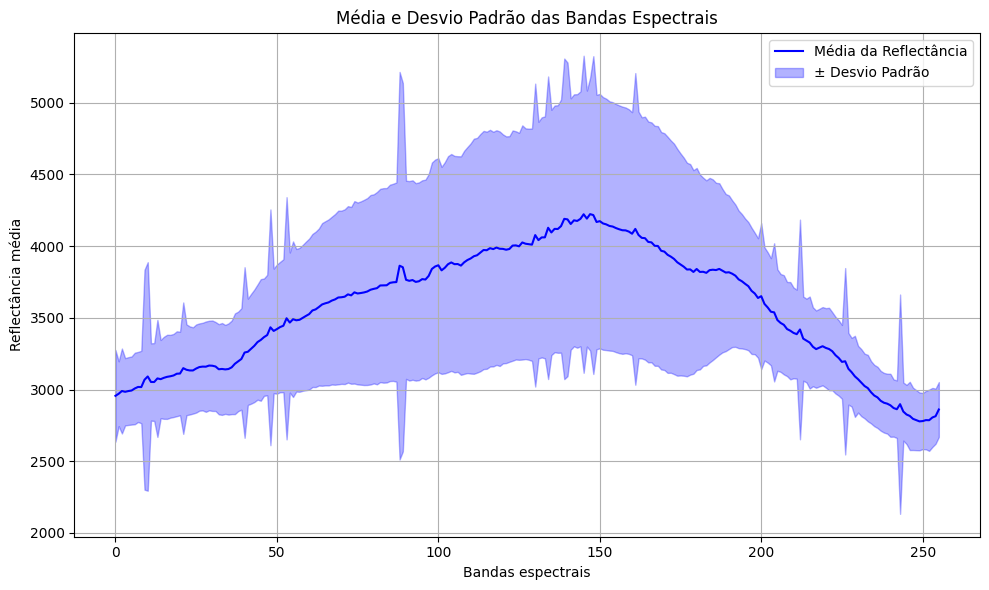

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image

# 📂 Caminho da imagem hiperespectral
caminho_imagem = r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\351_1_240506-160920.hdr"

# 🖼️ Abrir imagem hiperespectral
img = open_image(caminho_imagem).load()

# 📊 Calcular média e desvio padrão por banda
mean_spectrum = img.mean(axis=(0, 1))  # média por banda
std_spectrum = img.std(axis=(0, 1))    # desvio padrão por banda

# 📏 Eixo X: número de bandas
num_bandas = img.shape[2]
bandas = np.arange(num_bandas)  # ou use os comprimentos de onda reais se tiver

# 🎨 Plotar gráfico com faixa de desvio padrão
plt.figure(figsize=(10, 6))
plt.plot(bandas, mean_spectrum, label='Média da Reflectância', color='blue')
plt.fill_between(bandas, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                 color='blue', alpha=0.3, label='± Desvio Padrão')
plt.xlabel('Bandas espectrais')
plt.ylabel('Reflectância média')
plt.title('Média e Desvio Padrão das Bandas Espectrais')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\.venv\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)
C:\Users\LucAA\AppData\Local\Temp\ipykernel_16984\3265239667.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  roi = img * mask3d


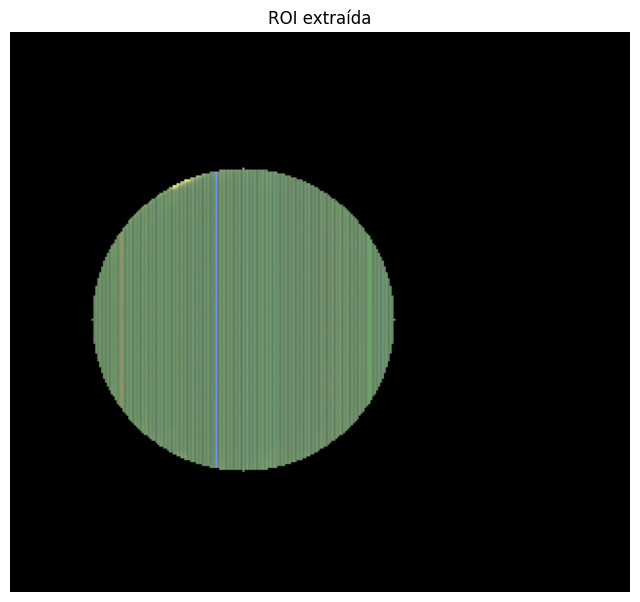

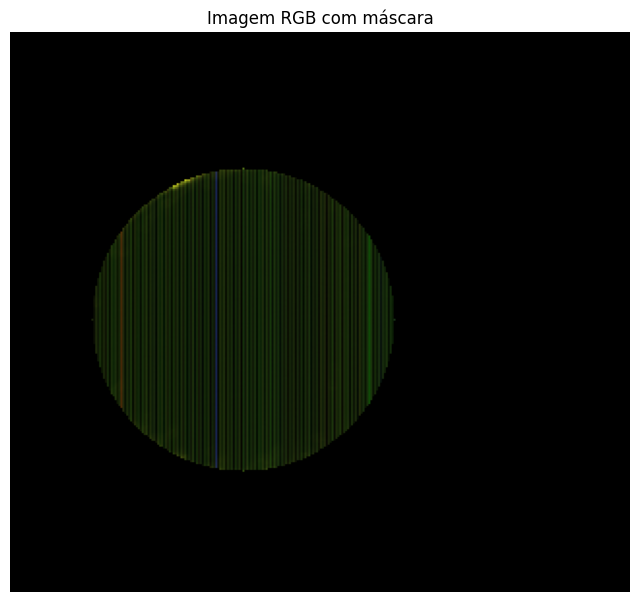

In [4]:
import spectral
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho =  r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\351_1_240506-160920.hdr"

img = spectral.open_image(caminho).load()
rgb = spectral.get_rgb(img,[50,30, 10])

gray = cv2.cvtColor((rgb *255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray,(7,7),2)

circles = cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,1.2,100,param1=100,param2=30,minRadius=50,maxRadius=200)
mask = np.zeros(gray.shape,dtype=np.uint8)
x,y,r= circles[0][0]
cv2.circle(mask,(int(x),int(y)),int(r),1,thickness=-1)

mask3d = np.repeat(mask[:,:,np.newaxis],img.shape[2],axis=2)
roi = img * mask3d

roi_rgb = spectral.get_rgb(roi, [50, 30, 10])

plt.figure(figsize=(8,8))
plt.imshow(roi_rgb)
plt.axis("off")
plt.title("ROI extraída")
plt.show()

masked_rgb = rgb * mask[:,:,np.newaxis]

plt.figure(figsize=(8,8))
plt.imshow(masked_rgb)
plt.axis("off")
plt.title("Imagem RGB com máscara")
plt.show()